#  Notebook 2 — Modelo Baseline
## HMDA New York 2024: Sesgo, Equidad y Explicabilidad en Hipotecas

**Autores:** Izan Cuesta Corbí · Dennis García Solera · Marcos Segurado Llopis · Jesús Cano Moya  
**Dataset:** Home Mortgage Disclosure Act (HMDA) — New York 2024 (CFPB)

---
> **Objetivo de este notebook:** Entrenamiento y evaluación del modelo baseline de Regresión Logística. Se mostraran las métricas de rendimiento y fairness de referencia (demographic parity, equalized odds) sobre las que se compararán los modelos posteriores.

> `RANDOM_STATE = 42` fijado globalmente para reproducibilidad.

--- 

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
os.makedirs('../outputs/images', exist_ok=True)

# Estilos globales para todos los gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style='whitegrid', palette='muted')

---
---

## Conjunto de Datos

---

### Carga del dataset

In [3]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head()

Train: (226665, 81)
Test:  (56667, 81)


,derived_msa-md,county_code,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,...,derived_race_Black or African American,derived_race_Free Form Text Only,derived_race_Joint,derived_race_Native Hawaiian or Other Pacific Islander,derived_race_Race Not Available,derived_race_White,derived_sex_Female,derived_sex_Joint,derived_sex_Male,derived_sex_Sex Not Available
0,-0.053043,-0.136364,0.0,0.0,9.666667,1.0,0.0,1.0,0.0,-0.030303,...,False,False,False,False,False,True,False,True,False,False
1,5.598696,0.772727,0.0,0.0,-0.333333,0.0,0.0,0.0,0.0,-0.303030,...,False,False,False,False,False,True,False,False,True,False
2,-1.898609,-1.318182,0.0,0.0,0.666667,1.0,0.0,0.0,0.0,-0.545455,...,False,False,False,False,False,True,False,True,False,False
3,0.414435,-0.227273,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,-0.272727,...,False,False,False,False,True,False,False,False,False,True
4,0.000000,0.363636,0.0,0.0,9.666667,0.0,0.0,0.0,1.0,0.696970,...,False,False,False,False,True,False,True,False,False,False


---
### Selección de Columnas

In [20]:
FEATURE_COLS = [col for col in train.columns if col != 'action_taken']
print(f"Nº de features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Nº de features: 80
Features: ['derived_msa-md', 'county_code', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score_type', 'co-applicant_credit_score_type', 'applicant_ethnicity-1', 'co-applicant_ethnicity-1', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race-1', 'co-applicant_race-1', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex', 'co-applicant_sex', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age', 'applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'aus-1

---
### Separación de Train/Test

In [21]:
X_train = train[FEATURE_COLS] # columnas que entran al modelo 
y_train = train['action_taken'] # columna que queremos predecir

X_test = test[FEATURE_COLS] 
y_test = test['action_taken'] 

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (226665, 80)
X_test:  (56667, 80)


---
---

## Modelo Baseline

---
### Definición del modelo 

En este notebook entrenamos un modelo de **Regresión Logística** como baseline. Al ser el modelo lineal más simple para clasificación binaria, nos servirá como referencia para cuantificar la mejora real que aportarán los modelos más complejos en notebooks posteriores, tanto en rendimiento como en equidad.

Al tratarse de un modelo de referencia, el objetivo es mantenerlo lo más simple posible. Por eso dejamos la mayoría de parámetros en sus valores por defecto y solo ajustamos los estrictamente necesarios:

| Parámetro | Valor | Justificación |
|---|---|---|
| `C` | `1.0` | Regularización estándar, sin ajuste |
| `penalty` | `'l2'` | Regularización Ridge por defecto |
| `solver` | `'lbfgs'` | Optimizador por defecto, adecuado para datasets grandes |
| `max_iter` | `1000` | Aumentado desde 100 para garantizar convergencia en un dataset grande como el nuestro |
| `class_weight` | `'balanced'` | Compensa el desbalance ~74/26 para evitar que el modelo ignore la clase minoritaria |
| `random_state` | `42` | Fijado globalmente para garantizar reproducibilidad |

In [22]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

---
### Entrenamiento del modelo

In [23]:
lr_baseline.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

---
### Predicción

In [29]:
y_pred = lr_baseline.predict(X_test)
y_prob = lr_baseline.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva (para ROC-AUC)

---
---

## Resultados

---
### Métricas


Una vez entrenado el modelo, evaluamos su rendimiento global sobre el conjunto de test mediante tres métricas complementarias. El **Accuracy** mide la proporción de predicciones correctas sobre el total, el **F1-Score** pondera precisión y recall siendo especialmente útil ante el desbalance ~74/26 del dataset, y el **ROC-AUC** evalúa la capacidad discriminativa del modelo a lo largo de todos los umbrales de decisión posibles, siendo independiente del umbral de clasificación por defecto de 0.5.

In [30]:
print("=" * 50)
print("MÉTRICAS BASELINE — REGRESIÓN LOGÍSTICA")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred))

MÉTRICAS BASELINE — REGRESIÓN LOGÍSTICA

Accuracy:  0.7120
F1-Score:  0.7874
ROC-AUC:   0.7697

Classification Report:

              precision    recall  f1-score   support

           0       0.47      0.68      0.55     14909
           1       0.86      0.72      0.79     41758

    accuracy                           0.71     56667
   macro avg       0.67      0.70      0.67     56667
weighted avg       0.76      0.71      0.73     56667



El modelo baseline alcanza un Accuracy de 0.7120 y un ROC-AUC de 0.7697, lo que indica una capacidad discriminativa moderada esperada para un modelo lineal simple. El F1-Score de 0.7874 sobre la clase mayoritaria (aprobaciones) contrasta con el 0.55 de la clase minoritaria (denegaciones), reflejando la dificultad del modelo para identificar correctamente las solicitudes denegadas a pesar del uso de `class_weight='balanced'`. Estos valores servirán como referencia para cuantificar la mejora aportada por los modelos posteriores.

---
### Matriz de confusión


Incluimos la matriz de confusión porque en el contexto de aprobación de hipotecas los errores no tienen el mismo coste. Denegar una hipoteca a alguien que sí la merece(Falso Negativo) tiene implicaciones sociales y legales muy distintas a aprobarla a alguien que no puede pagarla (Falso Positivo). La matriz nos permite ver
exactamente cuántos errores de cada tipo comete el modelo, algo que el accuracy por sí solo no refleja.

DESGLOSE DE PREDICCIONES
Verdaderos Negativos (TN):  10,121  → denegaciones correctamente identificadas
Falsos Positivos     (FP):   4,788  → denegaciones predichas como aprobaciones
Falsos Negativos     (FN):  11,533  → aprobaciones predichas como denegaciones
Verdaderos Positivos (TP):  30,225  → aprobaciones correctamente identificadas
Total:                      56,667


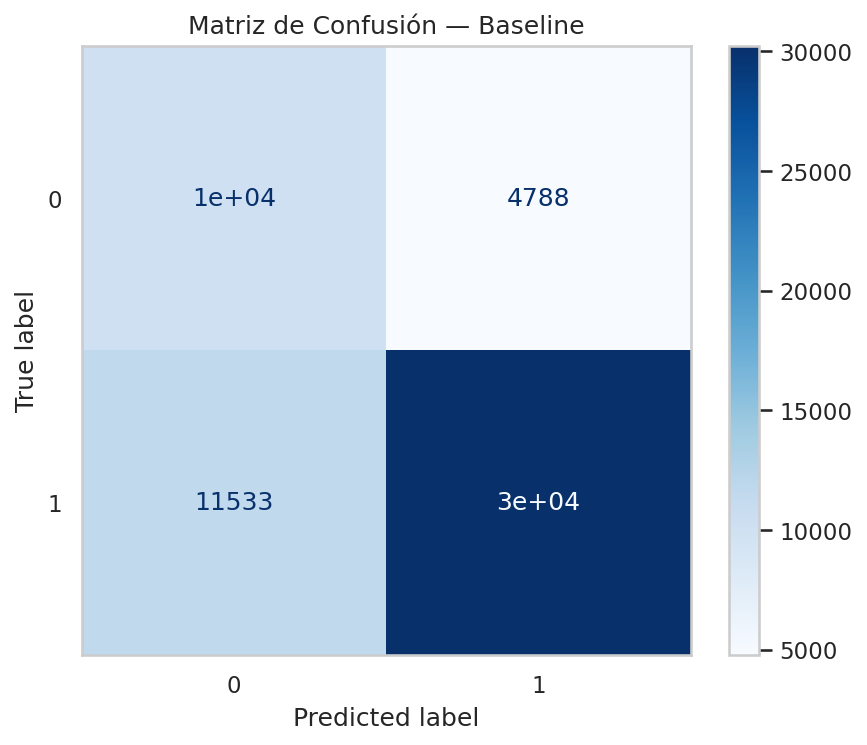

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,colorbar=True,cmap='Blues')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("DESGLOSE DE PREDICCIONES")
print("=" * 40)
print(f"Verdaderos Negativos (TN): {tn:>7,}  → denegaciones correctamente identificadas")
print(f"Falsos Positivos     (FP): {fp:>7,}  → denegaciones predichas como aprobaciones")
print(f"Falsos Negativos     (FN): {fn:>7,}  → aprobaciones predichas como denegaciones")
print(f"Verdaderos Positivos (TP): {tp:>7,}  → aprobaciones correctamente identificadas")
print("=" * 40)
print(f"Total:                     {tn+fp+fn+tp:>7,}")
ax.set_title("Matriz de Confusión — Baseline")
ax.grid(False)
plt.tight_layout()
plt.savefig('../outputs/images/matriz_confusion_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

La matriz confirma el desequilibrio en los errores del modelo. De las 14.909 denegaciones reales, el modelo identifica correctamente 10.121 (TN) pero falla en 4.788 (FP), aprobando solicitudes que deberían haberse denegado. Más importante aún, de las 41.758 aprobaciones reales, 11.533 son clasificadas incorrectamente como denegaciones (FN), lo que en el contexto real implica rechazar solicitudes legítimas de hipoteca. Este tipo de error tiene consecuencias sociales directas sobre las personas afectadas y será uno de los focos del análisis de fairness posterior.

---
### Curva ROC


Hemos incluido la curva ROC porque nos permite evaluar el rendimiento del modelo a lo largo de todos los umbrales de decisión posibles, no solo el 0.5 por defecto. El área bajo la curva (AUC) resume esto en un único valor comparable entre modelos. Esto será especialmente útil en notebooks posteriores, donde podremos superponer la curva del baseline con la del Gradient Boosting para visualizar de forma directa la mejora obtenida.

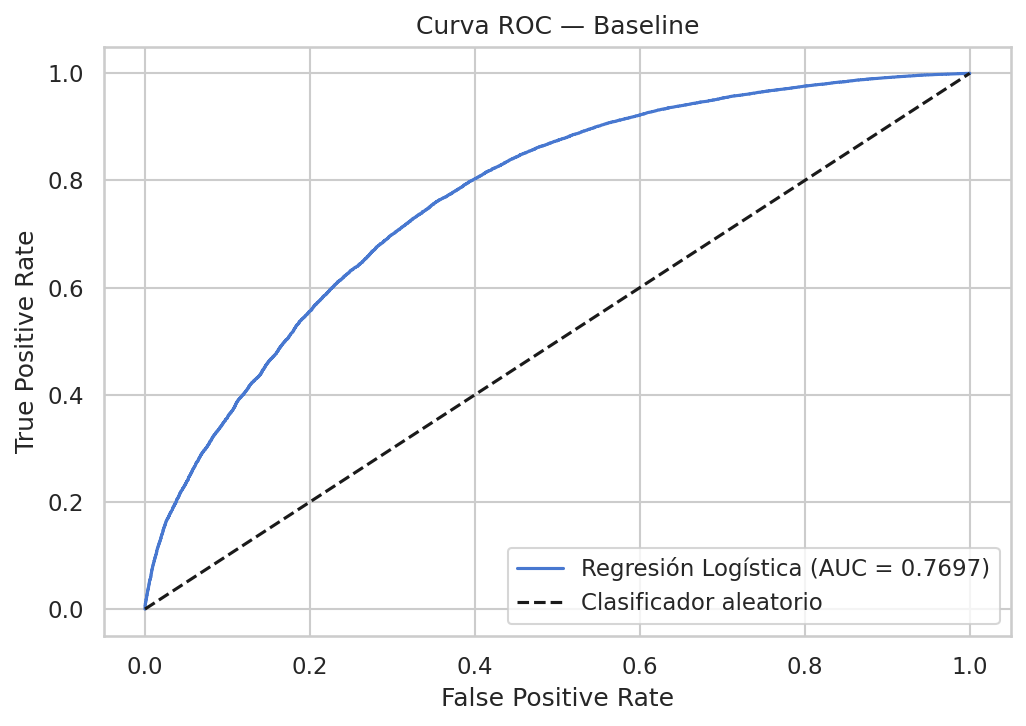

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Baseline')
plt.legend()
plt.tight_layout()
plt.show()

La curva ROC muestra que el modelo baseline se aleja del clasificador aleatorio (AUC = 0.7697), lo que indica una capacidad discriminativa moderada. La curva presenta una subida pronunciada al principio, lo que significa que el modelo es capaz de identificar correctamente una buena parte de las aprobaciones con una tasa de falsos positivos baja. Sin embargo, el AUC de 0.7697 deja margen de mejora considerable respecto a lo que se espera de un modelo más complejo como el Gradient Boosting de los notebooks posteriores. Este valor lo almacenaremos como referencia para futuras comparaciones.

---
### Análisis de Fairness

Más allá del rendimiento global, nosotros vamos a evaluar si el modelo toma decisiones equitativas entre grupos demográficos. Para ello calculamos dos métricas estándar de fairness sobre los atributos sensibles `derived_race`, `derived_sex` y `derived_ethnicity`:

- **Demographic Parity (Paridad Demográfica):** mide si la tasa de predicciones positivas (aprobación) es igual entre grupos. Un modelo justo debería aprobar hipotecas a la misma tasa independientemente de la raza, sexo o etnia.

- **Equalized Odds:** mide si la tasa de Verdaderos Positivos (TPR) y de Falsos Positivos (FPR) es igual entre grupos. Es más exigente que la paridad demográfica porque no solo mira cuánto aprueba el modelo, sino si se equivoca igual con todos los grupos.

In [33]:
def fairness_report(y_true, y_pred, X, sensitive_prefix):
    """
    Calcula métricas de fairness para cada subgrupo de una variable sensible.
    Parámetros:
        y_true: valores reales
        y_pred: predicciones del modelo
        X: DataFrame con todas las columnas
        sensitive_prefix: prefijo de la variable sensible (ej: 'derived_race_')
    """
    # Seleccionamos las columnas del grupo sensible
    cols = [c for c in X.columns if c.startswith(sensitive_prefix)]
    
    resultados = []
    for col in cols:
        # Máscara del subgrupo (filas donde esa categoría es 1)
        mask = X[col].reset_index(drop=True) == 1
        if mask.sum() < 50:  # ignoramos grupos con menos de 50 instancias
            continue
            
        yt = y_true.reset_index(drop=True)[mask]
        yp = pd.Series(y_pred)[mask]
        
        # Demographic Parity: tasa de predicciones positivas
        approval_rate = (yp == 1).mean()
        
        # Equalized Odds: TPR y FPR
        tp = ((yt == 1) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
        
        nombre = col.replace(sensitive_prefix, '')
        resultados.append({
            'Grupo': nombre,
            'N': mask.sum(),
            'Approval Rate (DP)': round(approval_rate, 4),
            'TPR': round(tpr, 4),
            'FPR': round(fpr, 4)
        })
    
    return pd.DataFrame(resultados).sort_values('Approval Rate (DP)', ascending=False)

#### Fairness por raza

In [34]:
print("FAIRNESS — RAZA")
print("=" * 60)
df_raza = fairness_report(y_test, y_pred, X_test, 'derived_race_')
print(df_raza.to_string(index=False))

FAIRNESS — RAZA
                                    Grupo     N  Approval Rate (DP)    TPR    FPR
                                    Joint   953              0.7681 0.8424 0.4469
                                    White 35847              0.6685 0.7595 0.3706
                                    Asian  5135              0.6574 0.7684 0.3183
                       Race Not Available  9695              0.5462 0.6596 0.2862
                 2 or more minority races   141              0.4468 0.6164 0.2647
         American Indian or Alaska Native   249              0.3655 0.5077 0.2101
                Black or African American  4493              0.3229 0.4364 0.1634
Native Hawaiian or Other Pacific Islander   130              0.2385 0.4348 0.0164


Los resultados por raza revelan diferencias significativas en la tasa de aprobación. Las personas blancas obtienen una tasa de aprobación del 66.85%, mientras que las personas negras o afroamericanas solo alcanzan el 32.29%, una diferencia de más de 34 puntos porcentuales. Esta brecha se confirma también en el TPR: el modelo identifica correctamente el 75.95% de las aprobaciones reales en personas blancas frente al 43.64% en personas negras, lo que indica que el modelo no solo aprueba menos a este grupo sino que también falla más en identificar sus solicitudes legítimas. El grupo Native Hawaiian or Other Pacific Islander presenta la tasa más baja con un 23.85%, aunque su tamaño muestral reducido (N=130) limita la solidez estadística de este resultado.

#### Fairness por sexo

In [35]:
print("FAIRNESS — SEXO")
print("=" * 60)
df_sexo = fairness_report(y_test, y_pred, X_test, 'derived_sex_')
print(df_sexo.to_string(index=False))

FAIRNESS — SEXO
            Grupo     N  Approval Rate (DP)    TPR    FPR
            Joint 18386              0.7659 0.8399 0.4566
Sex Not Available  4940              0.6164 0.7081 0.3818
           Female 13481              0.5465 0.6669 0.2672
             Male 19860              0.5297 0.6428 0.2625


Los resultados por sexo muestran diferencias más moderadas que las observadas por raza, aunque igualmente presentes. Las solicitudes conjuntas (Joint) obtienen la tasa de aprobación más alta con un 76.59%, lo cual es esperable ya que dos solicitantes combinan ingresos y reducen el riesgo percibido. Entre los grupos individuales, las mujeres (54.65%) superan ligeramente a los hombres (52.97%) con una diferencia de apenas 1.7 puntos porcentuales, lo que sugiere que el sexo tiene un impacto limitado en las predicciones del modelo baseline. Sin embargo, el grupo `Sex Not Available` alcanza un 61.64%, lo que podría indicar un sesgo introducido por la ausencia de información más que por el sexo en sí.

#### Fairness por etnia

In [36]:
print("FAIRNESS — ETNIA")
print("=" * 60)
df_etnia = fairness_report(y_test, y_pred, X_test, 'derived_ethnicity_')
print(df_etnia.to_string(index=False))

FAIRNESS — ETNIA
                  Grupo     N  Approval Rate (DP)    TPR    FPR
                  Joint  1200              0.7025 0.7983 0.3922
 Not Hispanic or Latino 41660              0.6500 0.7493 0.3453
Ethnicity Not Available  8891              0.5727 0.6801 0.3117
     Hispanic or Latino  4891              0.4061 0.5327 0.1862


Los resultados por etnia muestran una brecha entre los grupos principales. Las personas no hispanas obtienen una tasa de aprobación del 65.00%, frente al 40.61% de las personas hispanas o latinas, una diferencia de más de 24 puntos porcentuales. Esta disparidad se refleja también en el TPR: el modelo identifica correctamente el 74.93% de las aprobaciones reales en personas no hispanas frente al 53.27% en personas hispanas, lo que indica que el modelo comete más errores de tipo Falso Negativo sobre este grupo, denegando solicitudes legítimas con mayor frecuencia. Al igual que en el análisis por raza, estos resultados anticipan la necesidad de aplicar técnicas de mitigación de sesgo en los notebooks posteriores.

#### Visualización

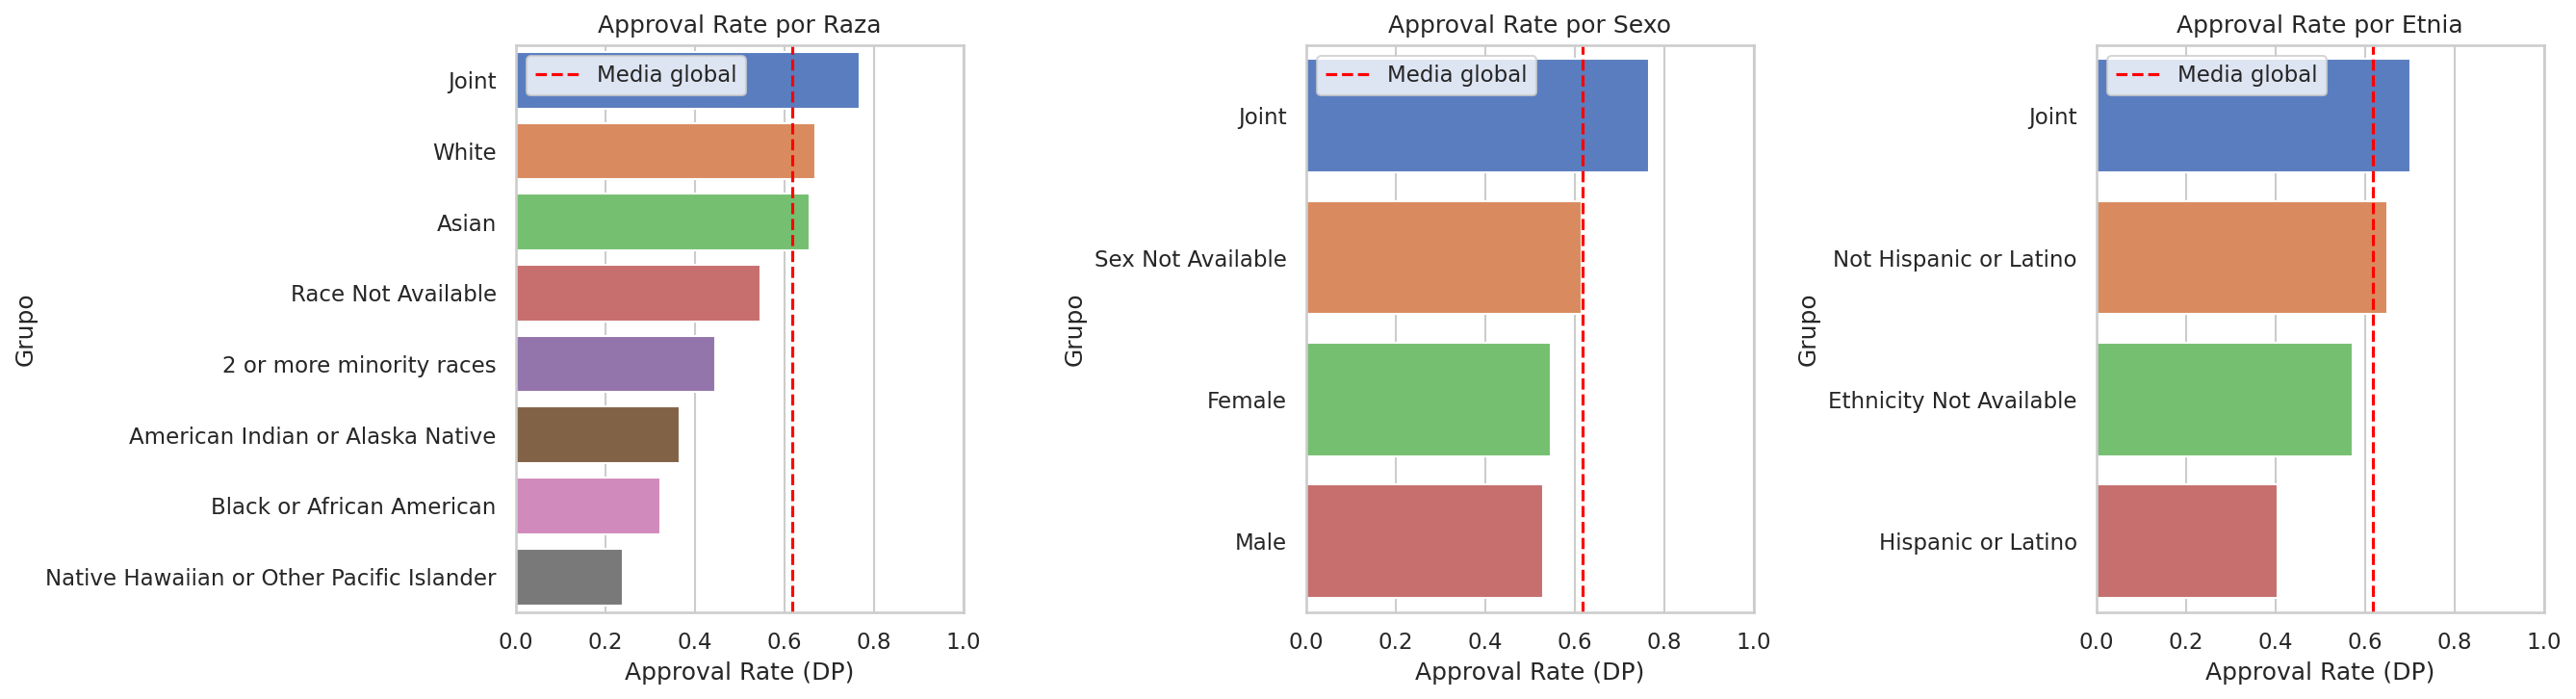

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df_group, titulo) in zip(axes, [
    (df_raza,  'Approval Rate por Raza'),
    (df_sexo,  'Approval Rate por Sexo'),
    (df_etnia, 'Approval Rate por Etnia')
]):
    sns.barplot(data=df_group, x='Approval Rate (DP)', y='Grupo', ax=ax, palette='muted')
    ax.set_title(titulo)
    ax.set_xlim(0, 1)
    ax.axvline(x=y_pred.mean(), color='red', linestyle='--', label='Media global')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/images/fairness_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

Los gráficos de Approval Rate confirman visualmente las disparidades detectadas en las tablas anteriores. En los tres atributos sensibles analizados se observa que determinados grupos quedan sistemáticamente por debajo de la media global (línea roja discontinua): personas negras y Native Hawaiian en raza, personas hispanas en etnia, y en menor medida mujeres en sexo.

Estos resultados establecen las métricas de fairness de referencia del baseline sobre las que se medirá el impacto de las técnicas de mitigación aplicadas en notebooks posteriores. Un modelo con mejor rendimiento global no implica necesariamente un modelo más justo, y esta tensión entre rendimiento y equidad será el eje central del análisis comparativo final.